### Libraries, data and Functions

In [12]:
import sys
import os

# Agrega el directorio anterior al sys.path
sys.path.append(os.path.abspath(".."))


import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import my_module as mm
from scipy import stats
import importlib
import scipy.linalg as la
from getdist import MCSamples, plots
from scipy.constants import c

#Refresh the changes made on my_module files
importlib.reload(mm)


#Matplotlib parameters

plt.rcParams.update({
    # Font
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # Or your preferred from the list
    "font.size": 14,                 # Base font size for all text

    # Axes labels & title sizes
    "axes.titlesize": 16,
    "axes.labelsize": 14,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

})

plt.rcParams['text.usetex'] = True

In [13]:
def split_dataframe(df, chunk_size):
    return [df[i:i + chunk_size] for i in range(0, len(df), chunk_size)]

def meme_bins(data, col='zHD'):

    medians_h0 = []
    means_h0 = []
    desvest_h0 = []
    midpoint = []

    for i in range(len(data)):
        medians_h0.append(np.median(data[i]['H_0']))
        means_h0.append(np.mean(data[i]['H_0']))
        desvest_h0.append(np.std(data[i]['H_0']))

        midpoint.append((min(data[i][col]) + max(data[i][col]))/2)

    return medians_h0, means_h0, desvest_h0, midpoint

In [14]:
#Pantheon+ data import
data_Pan, cov_Pan = mm.data_import.Pantheon_data()

#DES data import
data_DES, cov_DES = mm.data_import.DES_data()


data_DES['H_0'] = mm.FlatModel.hubble_const(data_DES['zHD'], data_DES['MU_SH0ES'])
data_Pan['H_0'] = mm.FlatModel.hubble_const(data_Pan['zHD'], data_Pan['MU_SH0ES'])

data_DES = data_DES.sort_values(by='zHD')
data_Pan = data_Pan.sort_values(by='zHD')

hubble_const_ref_Pan = mm.FlatModel.hubble_const(data_Pan['zHD'], data_Pan['MU_SH0ES'])
hubble_const_ref_DES = mm.FlatModel.hubble_const(data_DES['zHD'], data_DES['MU_SH0ES']) 

data_Pan['H_0'] = hubble_const_ref_Pan
data_DES['H_0'] = hubble_const_ref_DES

In [23]:
text_folder = '../../text/images/'

### Classical analysis

In [24]:
DES_dataPan = data_Pan[data_Pan['IDSURVEY'] == 10]
FOUND_dataPan = data_Pan[data_Pan['IDSURVEY'] == 150]
CFA3K_dataPan = data_Pan[data_Pan['IDSURVEY'] == 64]
CFA3S_dataPan = data_Pan[data_Pan['IDSURVEY'] == 63]
CFA4p2_dataPan = data_Pan[data_Pan['IDSURVEY'] == 65]
CFA4p3_dataPan = data_Pan[data_Pan['IDSURVEY'] == 66]

DES_dataDES = data_DES[data_DES['IDSURVEY'] == 10]
FOUND_dataDES = data_DES[data_DES['IDSURVEY'] == 150]
CFA3K_dataDES = data_DES[data_DES['IDSURVEY'] == 64]
CFA3S_dataDES = data_DES[data_DES['IDSURVEY'] == 63]
CFA4p2_dataDES = data_DES[data_DES['IDSURVEY'] == 65]
CFA4p3_dataDES = data_DES[data_DES['IDSURVEY'] == 66]

bins_DES_Pan = split_dataframe(DES_dataPan, 50)
bins_FOUND_Pan = split_dataframe(FOUND_dataPan, 50)
bins_CFA3K_Pan = split_dataframe(CFA3K_dataPan, 50)
bins_CFA3S_Pan = split_dataframe(CFA3S_dataPan, 50)
bins_CFA4p2_Pan = split_dataframe(CFA4p2_dataPan, 50)
bins_CFA4p3_Pan = split_dataframe(CFA4p3_dataPan, 50)

bins_DES_DES = split_dataframe(DES_dataDES, 50)
bins_FOUND_DES = split_dataframe(FOUND_dataDES, 50)
bins_CFA3K_DES = split_dataframe(CFA3K_dataDES, 50)
bins_CFA3S_DES = split_dataframe(CFA3S_dataDES, 50)
bins_CFA4p2_DES = split_dataframe(CFA4p2_dataDES, 50)
bins_CFA4p3_DES = split_dataframe(CFA4p3_dataDES, 50)

medians_DES_Pan, means_DES_Pan, desvest_DES_Pan, midpoint_DES_Pan = meme_bins(bins_DES_Pan)
medians_FOUND_Pan, means_FOUND_Pan, desvest_FOUND_Pan, midpoint_FOUND_Pan = meme_bins(bins_FOUND_Pan)
medians_CFA3K_Pan, means_CFA3K_Pan, desvest_CFA3K_Pan, midpoint_CFA3K_Pan = meme_bins(bins_CFA3K_Pan)
medians_CFA3S_Pan, means_CFA3S_Pan, desvest_CFA3S_Pan, midpoint_CFA3S_Pan = meme_bins(bins_CFA3S_Pan)
medians_CFA4p2_Pan, means_CFA4p2_Pan, desvest_CFA4p2_Pan, midpoint_CFA4p2_Pan = meme_bins(bins_CFA4p2_Pan)
medians_CFA4p3_Pan, means_CFA4p3_Pan, desvest_CFA4p3_Pan, midpoint_CFA4p3_Pan = meme_bins(bins_CFA4p3_Pan)

medians_DES_DES, means_DES_DES, desvest_DES_DES, midpoint_DES_DES = meme_bins(bins_DES_DES)
medians_FOUND_DES, means_FOUND_DES, desvest_FOUND_DES, midpoint_FOUND_DES = meme_bins(bins_FOUND_DES)
medians_CFA3K_DES, means_CFA3K_DES, desvest_CFA3K_DES, midpoint_CFA3K_DES = meme_bins(bins_CFA3K_DES)
medians_CFA3S_DES, means_CFA3S_DES, desvest_CFA3S_DES, midpoint_CFA3S_DES = meme_bins(bins_CFA3S_DES)
medians_CFA4p2_DES, means_CFA4p2_DES, desvest_CFA4p2_DES, midpoint_CFA4p2_DES = meme_bins(bins_CFA4p2_DES)
medians_CFA4p3_DES, means_CFA4p3_DES, desvest_CFA4p3_DES, midpoint_CFA4p3_DES = meme_bins(bins_CFA4p3_DES)

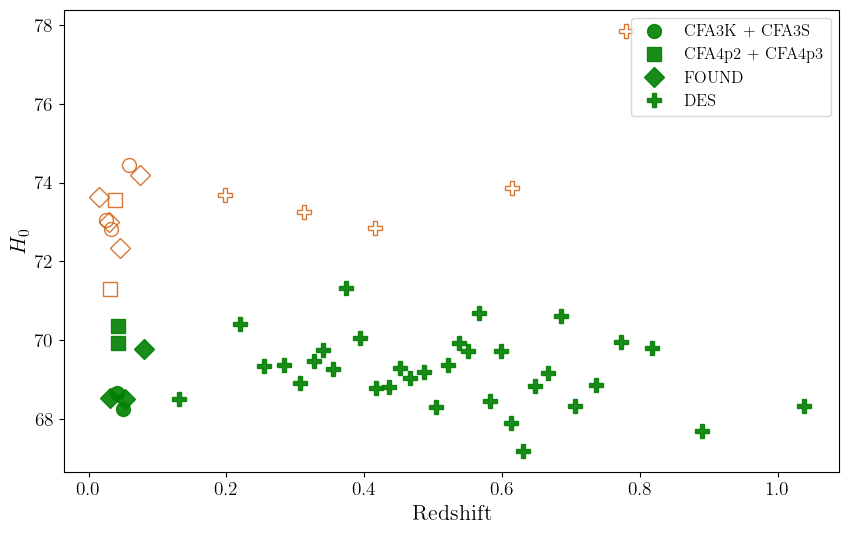

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(midpoint_CFA3K_Pan, medians_CFA3K_Pan, 'o', color='chocolate', mfc='none', markersize=10, alpha=0.9)
plt.plot(midpoint_CFA3S_Pan, medians_CFA3S_Pan, 'o', color='chocolate', mfc='none', markersize=10, alpha=0.9)
plt.plot(midpoint_CFA4p2_Pan, medians_CFA4p2_Pan, 's', color='chocolate', mfc='none', markersize=10, alpha=0.9)
plt.plot(midpoint_CFA4p3_Pan, medians_CFA4p3_Pan, 's', color='chocolate', mfc='none', markersize=10, alpha=0.9)
plt.plot(midpoint_FOUND_Pan, medians_FOUND_Pan, 'D', color='chocolate', mfc='none', markersize=10, alpha=0.9)
plt.plot(midpoint_DES_Pan, medians_DES_Pan, 'P', color='chocolate', mfc='none', markersize=10, alpha=0.9)
plt.plot(midpoint_CFA3K_DES, medians_CFA3K_DES, 'o', label='CFA3K + CFA3S', color='green', markersize=10, alpha=0.9)
plt.plot(midpoint_CFA3S_DES, medians_CFA3S_DES, 'o', color='green', markersize=10, alpha=0.9)
plt.plot(midpoint_CFA4p2_DES, medians_CFA4p2_DES, 's', label='CFA4p2 + CFA4p3', color='green', markersize=10, alpha=0.9)
plt.plot(midpoint_CFA4p3_DES, medians_CFA4p3_DES, 's', color='green', markersize=10, alpha=0.9)
plt.plot(midpoint_FOUND_DES, medians_FOUND_DES, 'D', label='FOUND', color='green', markersize=10, alpha=0.9)
plt.plot(midpoint_DES_DES, medians_DES_DES, 'P', label='DES', color='green', markersize=10, alpha=0.9)
#plt.xscale('log')
plt.xlabel('Redshift ', fontsize=16)
plt.ylabel(r'$H_0$', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12, loc='upper right')
plt.savefig(text_folder + 'survey_comparision.png', dpi=300, bbox_inches='tight')

### MCMC analysis

In [26]:
#Define parameter names and labels
param_names = ['om_m', 'H0']  
labels = [r'\Omega_m', r'H_0']

#data import from MCMC chains
data_Pan_DES = np.loadtxt("samples_DESonPan.txt")
data_Pan_FOUND = np.loadtxt("samples_FOUNDonPan.txt")
data_Pan_CF4 = np.loadtxt("samples_CFA4onPan.txt")
data_Pan_CF3 = np.loadtxt("samples_CFA3onPan.txt")

data_DES_DES = np.loadtxt("samples_DESonDES.txt")
data_DES_FOUND = np.loadtxt("samples_FOUNDonDES.txt")
data_DES_CF4 = np.loadtxt("samples_CFA4onDES.txt")
data_DES_CF3 = np.loadtxt("samples_CFA3onDES.txt")

#Convert it into MCSamples object
samples_Pan_DES = MCSamples(samples=data_Pan_DES, names=param_names, labels=labels)
samples_Pan_FOUND = MCSamples(samples=data_Pan_FOUND, names=param_names, labels=labels)
samples_Pan_CF4 = MCSamples(samples=data_Pan_CF4, names=param_names, labels=labels)
samples_Pan_CF3 = MCSamples(samples=data_Pan_CF3, names=param_names, labels=labels)

samples_DES_DES = MCSamples(samples=data_DES_DES, names=param_names, labels=labels)
samples_DES_FOUND = MCSamples(samples=data_DES_FOUND, names=param_names, labels=labels)
samples_DES_CF4 = MCSamples(samples=data_DES_CF4, names=param_names, labels=labels)
samples_DES_CF3 = MCSamples(samples=data_DES_CF3, names=param_names, labels=labels)

# Function to summarize MCSamples
def summarize_mc_samples(mc_sample, sample_name):
    """
    Print mean ± standard deviation for each parameter in an MCSamples object.
    
    Parameters
    ----------
    mc_sample : MCSamples
        MCSamples object containing the MCMC samples.
    """
    param_names = mc_sample.getParamNames().names
    for name in param_names:
        mean = mc_sample.mean(name)
        err = mc_sample.std(name)
        print(f"{sample_name} - {name}: {mean:.4f} ± {err:.4f}")

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


DES param on DES5yr - om_m	\Omega_m: 0.3052 ± 0.0351
DES param on DES5yr - H0	H_0: 68.8188 ± 0.8653
DES param on Pantheon+ - om_m	\Omega_m: 0.4449 ± 0.1751
DES param on Pantheon+ - H0	H_0: 72.2845 ± 3.2221


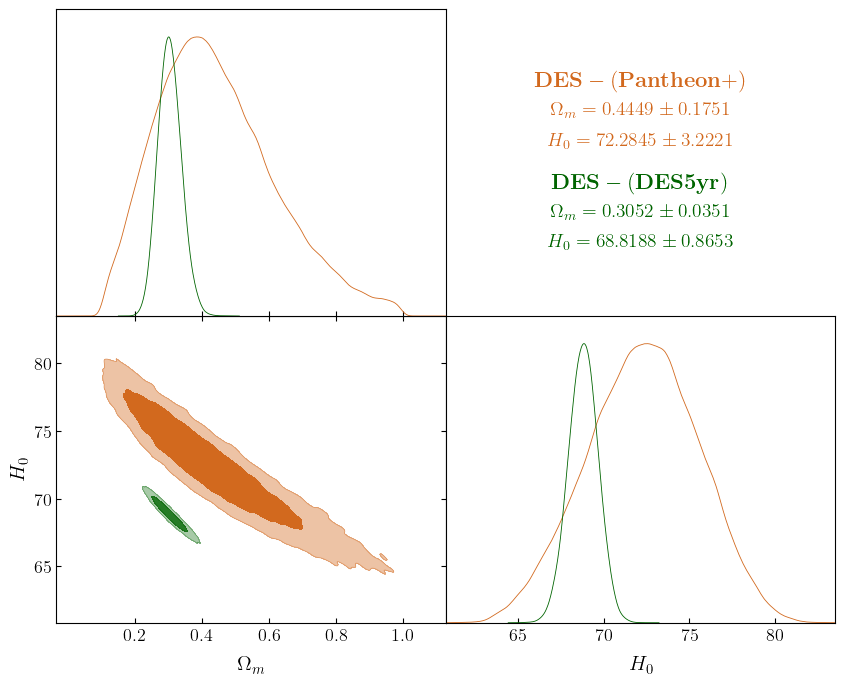

In [27]:
mm.make_triangle_plot(
    [samples_Pan_DES, samples_DES_DES],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'DES_survey_comparision.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['DES-(Pantheon+)', 'DES-(DES 5yr)']
)

summarize_mc_samples(samples_DES_DES, sample_name='DES param on DES5yr')
summarize_mc_samples(samples_Pan_DES, sample_name='DES param on Pantheon+')

FOUND param on DES5yr - om_m	\Omega_m: 0.5541 ± 0.2555
FOUND param on DES5yr - H0	H_0: 67.8783 ± 1.2905
FOUND param on Pantheon+ - om_m	\Omega_m: 0.5442 ± 0.2572
FOUND param on Pantheon+ - H0	H_0: 72.3556 ± 1.3654


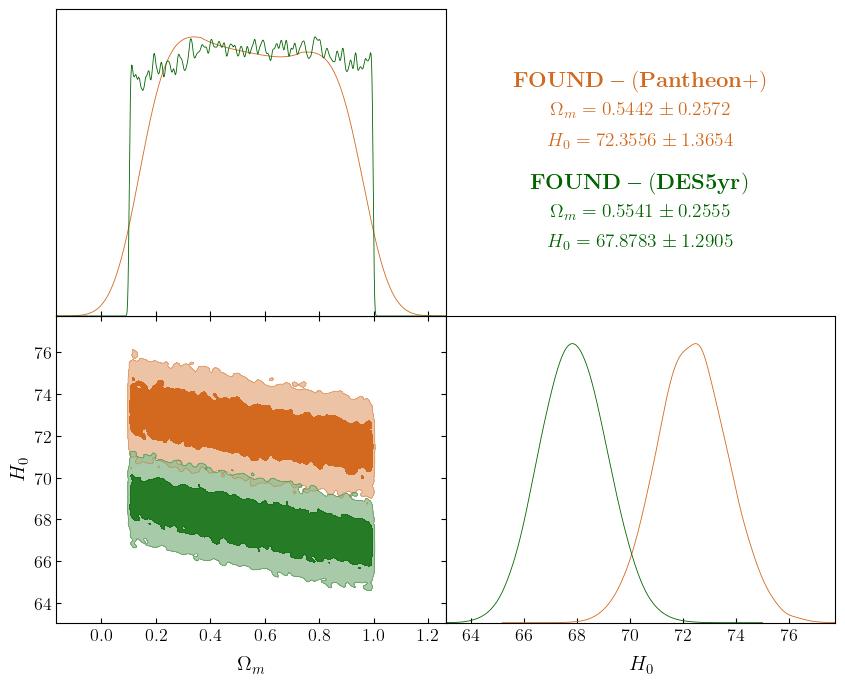

In [28]:
mm.make_triangle_plot(
    [samples_Pan_FOUND, samples_DES_FOUND],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'FOUND_survey_comparision.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['FOUND-(Pantheon+)', 'FOUND-(DES 5yr)']
)

summarize_mc_samples(samples_DES_FOUND, sample_name='FOUND param on DES5yr')
summarize_mc_samples(samples_Pan_FOUND, sample_name='FOUND param on Pantheon+')

CF4 param on DES5yr - om_m	\Omega_m: 0.5340 ± 0.2596
CF4 param on DES5yr - H0	H_0: 68.9144 ± 1.9223
CF4 param on Pantheon+ - om_m	\Omega_m: 0.5652 ± 0.2579
CF4 param on Pantheon+ - H0	H_0: 72.1772 ± 2.0495


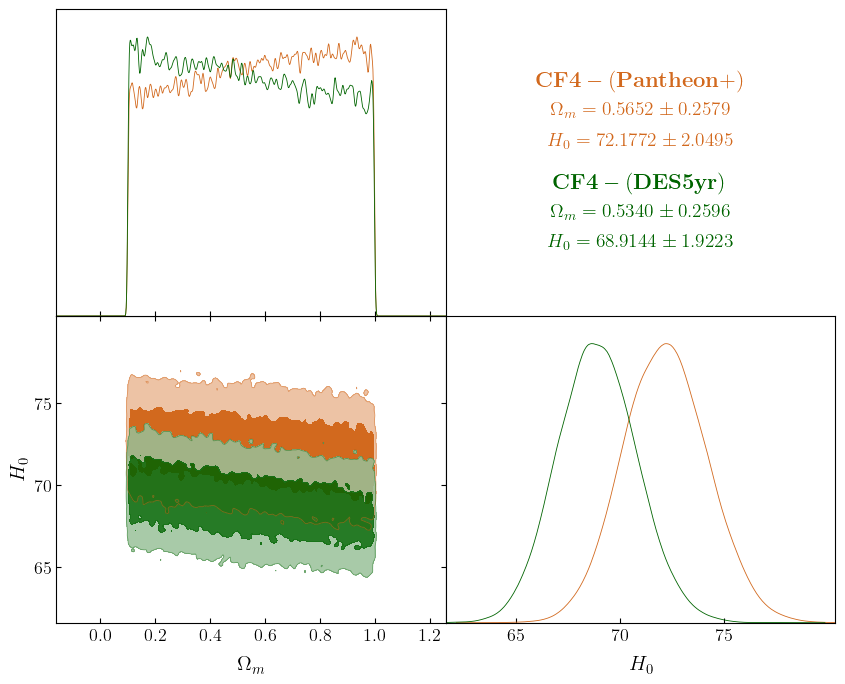

In [29]:
mm.make_triangle_plot(
    [samples_Pan_CF4, samples_DES_CF4],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'CF4_survey_comparision.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['CF4-(Pantheon+)', 'CF4-(DES 5yr)']
)

summarize_mc_samples(samples_DES_CF4, sample_name='CF4 param on DES5yr')
summarize_mc_samples(samples_Pan_CF4, sample_name='CF4 param on Pantheon+')

CF3 param on DES5yr - om_m	\Omega_m: 0.5618 ± 0.2585
CF3 param on DES5yr - H0	H_0: 69.6069 ± 2.0237
CF3 param on Pantheon+ - om_m	\Omega_m: 0.5568 ± 0.2569
CF3 param on Pantheon+ - H0	H_0: 72.9737 ± 1.5014


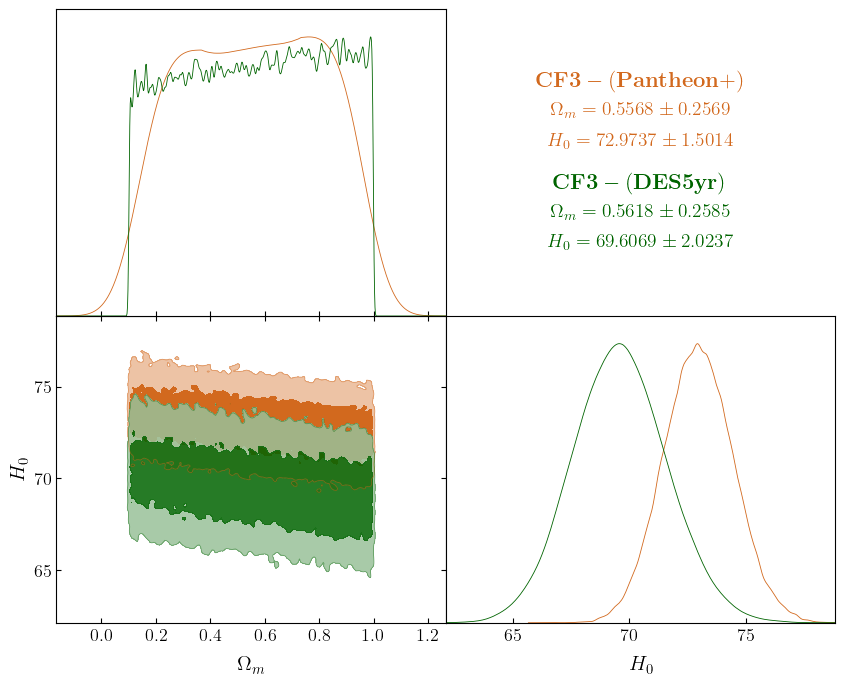

In [30]:
mm.make_triangle_plot(
    [samples_Pan_CF3, samples_DES_CF3],
    labels=labels,
    colors=('chocolate', 'darkgreen'),
    outfile=text_folder + 'CF3_survey_comparision.png',
    figsize=(10, 8),
    dpi=300,
    dataset_names=['CF3-(Pantheon+)', 'CF3-(DES 5yr)']
)

summarize_mc_samples(samples_DES_CF3, sample_name='CF3 param on DES5yr')
summarize_mc_samples(samples_Pan_CF3, sample_name='CF3 param on Pantheon+')